#  Sentiment Analysis on Hotel Reviews
Initial setup and data exploration.

### Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import joblib
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE

### Loading dataset

In [2]:
df = pd.read_csv("tripadvisor_hotel_reviews.csv")  
df.dropna(inplace=True)
df['Sentiment'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)  # 1 = positivo, 0 = negativo
df.head()

,Review,Rating,Sentiment
0,nice hotel expensive parking got good deal sta...,4,1
1,ok nothing special charge diamond member hilto...,2,0
2,nice rooms not 4* experience hotel monaco seat...,3,0
3,"unique, great stay, wonderful time hotel monac...",5,1
4,"great stay great stay, went seahawk game aweso...",5,1


### Visualisation

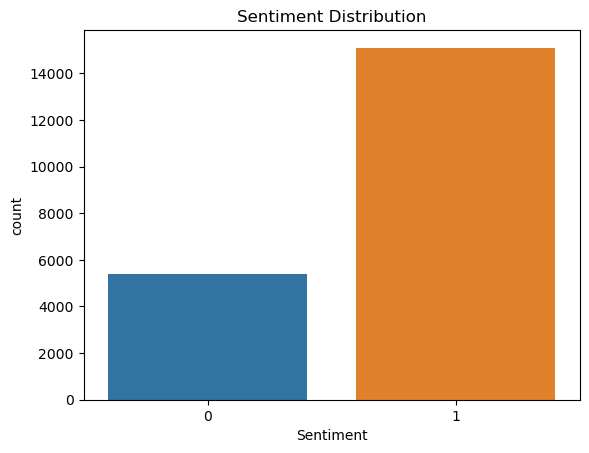

In [3]:
sns.countplot(data=df, x='Sentiment')
plt.title('Sentiment Distribution')
plt.show()

### Cleaning data

In [4]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuations and numbers
    text = re.sub(r"\bnot\s+(\w+)", r"not_\1", text)  # transform "not good" to "not_good"
    text = re.sub(r"n\\'t", " not", text)
    words = text.split()
    

    
    # Remove stopwords, but keep important words
    filtered_words = [word for word in words if word not in stop_words]
    
    return " ".join(filtered_words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)
df[['Review', 'Cleaned_Review']].head()





[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vankr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Review,Cleaned_Review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms not_experience hotel monaco seattle...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


### Split tain and test

In [5]:
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    df['Cleaned_Review'], df['Sentiment'], test_size=0.3, stratify=df['Sentiment'], random_state=42
)

### TF-IDF Vectorisation

In [6]:
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=7000, min_df=3)
X_train = tfidf.fit_transform(X_train_texts)
X_test = tfidf.transform(X_test_texts)

### Apply SMOTE for balancing the classes

In [7]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

### Logistic Regression

In [8]:
model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_res, y_res)

LogisticRegression(class_weight='balanced')

              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1620
           1       0.92      0.94      0.93      4528

    accuracy                           0.90      6148
   macro avg       0.88      0.86      0.87      6148
weighted avg       0.90      0.90      0.90      6148

ROC AUC: 0.9497837870261309


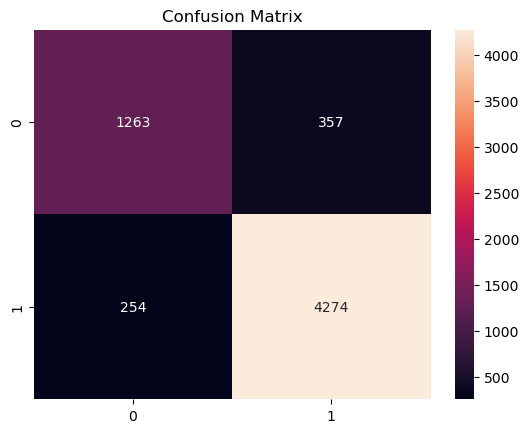

In [9]:
y_pred_lr = model_lr.predict(X_test)
y_pred_prob_lr = model_lr.predict_proba(X_test)
y_pred_adjusted_lr = (y_pred_prob_lr[:, 1] >= 0.4).astype(int)

print(classification_report(y_test, y_pred_adjusted_lr))
print("ROC AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]))
sns.heatmap(confusion_matrix(y_test, y_pred_adjusted_lr), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Random Forest

In [10]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', random_state=42)

              precision    recall  f1-score   support

           0       0.85      0.44      0.58      1620
           1       0.83      0.97      0.90      4528

    accuracy                           0.83      6148
   macro avg       0.84      0.71      0.74      6148
weighted avg       0.84      0.83      0.81      6148

ROC AUC: 0.9035619247044453


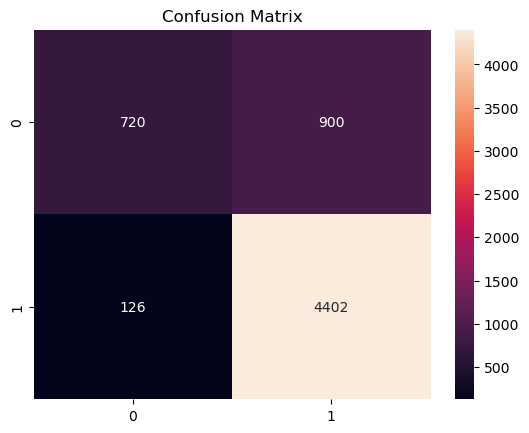

In [11]:
y_pred_rf = model_rf.predict(X_test)
y_pred_prob_rf = model_rf.predict_proba(X_test)
y_pred_adjusted_rf = (y_pred_prob_rf[:, 1] >= 0.4).astype(int)

print(classification_report(y_test, y_pred_adjusted_rf))
print("ROC AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))
sns.heatmap(confusion_matrix(y_test, y_pred_adjusted_rf), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Naive Bayes Model

In [12]:
model_nb = MultinomialNB()
model_nb.fit(X_res, y_res)

MultinomialNB()

              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1620
           1       0.91      0.91      0.91      4528

    accuracy                           0.87      6148
   macro avg       0.83      0.83      0.83      6148
weighted avg       0.87      0.87      0.87      6148

ROC AUC: 0.9236578709156743


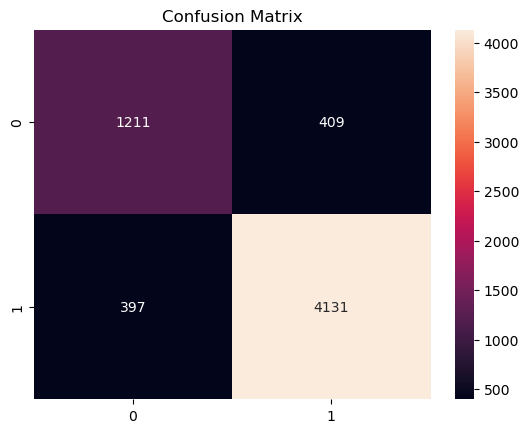

In [13]:
y_pred_nb = model_nb.predict(X_test)
y_pred_prob_nb = model_nb.predict_proba(X_test)
y_pred_adjusted_nb = (y_pred_prob_nb[:, 1] >= 0.4).astype(int)

print(classification_report(y_test, y_pred_adjusted_nb))
print("ROC AUC:", roc_auc_score(y_test, model_nb.predict_proba(X_test)[:,1]))
sns.heatmap(confusion_matrix(y_test, y_pred_adjusted_nb), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


In [14]:
# Save the model and TF-IDF vector
joblib.dump(model_lr, "model_lr.pkl")
joblib.dump(model_rf, "model_rf.pkl")
joblib.dump(model_nb, "model_nb.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']